# GCN - Cora Node Classification

A Graph Convolutional Network (GCN) is used to classify research papers in the Cora citation network. Each paper is represented as a node, citation relationships form the graph edges, and the paper's word features provide the node information used for classification.

The model learns by combining information from each paper with information from its neighboring papers. The notebook covers graph construction, adjacency normalization, semi-supervised training, model evaluation, error analysis, and visualization of the learned node representations.

# 1. Import Required Libraries

Load the libraries needed for data handling, graph construction, model training, and evaluation.

In [1]:
import os
import random
import time
import urllib.request
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


# 2. Configure Reproducibility and Training

Set the random seed, device, and training hyperparameters.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HIDDEN_DIM = 16
DROPOUT = 0.5
LEARNING_RATE = 0.01
WEIGHT_DECAY = 5e-4
MAX_EPOCHS = 200
PATIENCE = 30

print("Device:", DEVICE)


Device: cuda


# 3. Download and Load the Cora Dataset

Download the Cora citation-network files and load them locally.

In [3]:
DATA_ROOT = Path("/content/cora")
EXTRACT_ROOT = DATA_ROOT / "cora"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

content_path = EXTRACT_ROOT / "cora.content"
cites_path = EXTRACT_ROOT / "cora.cites"
archive_path = DATA_ROOT / "cora.tgz"

if not content_path.exists() or not cites_path.exists():
    url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"
    print("Downloading Cora...")
    urllib.request.urlretrieve(url, archive_path)

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(DATA_ROOT)

print("Cora loaded from:", EXTRACT_ROOT)


Cora loaded from: /content/cora/cora


/tmp/ipykernel_1167/2545773852.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_ROOT)


# 4. Explore the Dataset

Inspect the number of papers, features, citations, and research categories.

In [4]:
content = pd.read_csv(content_path, sep="\t", header=None)
cites = pd.read_csv(cites_path, sep="\t", header=None)

num_nodes = content.shape[0]
num_features = content.shape[1] - 2
num_edges = cites.shape[0]
class_names = sorted(content.iloc[:, -1].unique())
num_classes = len(class_names)

print(f"Nodes: {num_nodes}")
print(f"Features: {num_features}")
print(f"Citation edges: {num_edges}")
print(f"Classes: {num_classes}")
print("Class names:", class_names)


Nodes: 2708
Features: 1433
Citation edges: 5429
Classes: 7
Class names: ['Case_Based', 'Genetic_Algorithms', 'Neural_Networks', 'Probabilistic_Methods', 'Reinforcement_Learning', 'Rule_Learning', 'Theory']


# 5. Prepare Node Features and Labels

Convert paper features and class labels into tensors for the GCN.

In [5]:
node_ids = content.iloc[:, 0].astype(str).tolist()
id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}

X = content.iloc[:, 1:-1].to_numpy(dtype=np.float32)
labels = content.iloc[:, -1].astype(str).to_numpy()

label_to_idx = {label: i for i, label in enumerate(class_names)}
y = np.array([label_to_idx[label] for label in labels], dtype=np.int64)

row_sums = X.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
X = X / row_sums

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

print("Feature matrix:", X_tensor.shape)
print("Label tensor:", y_tensor.shape)


Feature matrix: torch.Size([2708, 1433])
Label tensor: torch.Size([2708])


# 6. Build the Citation Graph

Create the graph adjacency matrix and normalize it for message passing.

In [6]:
edges = []

for src, dst in cites.itertuples(index=False):
    src, dst = str(src), str(dst)

    if src in id_to_idx and dst in id_to_idx:
        i, j = id_to_idx[src], id_to_idx[dst]
        edges.append((i, j))
        edges.append((j, i))

for i in range(num_nodes):
    edges.append((i, i))

edge_array = np.asarray(edges, dtype=np.int64)

row = torch.tensor(edge_array[:, 0], dtype=torch.long)
col = torch.tensor(edge_array[:, 1], dtype=torch.long)
values = torch.ones(len(edge_array), dtype=torch.float32)

adj = torch.sparse_coo_tensor(
    torch.stack([row, col]),
    values,
    (num_nodes, num_nodes)
).coalesce()

degree = torch.sparse.sum(adj, dim=1).to_dense()
deg_inv_sqrt = degree.pow(-0.5)
deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

norm_values = deg_inv_sqrt[row] * values * deg_inv_sqrt[col]

adj_norm = torch.sparse_coo_tensor(
    torch.stack([row, col]),
    norm_values,
    (num_nodes, num_nodes)
).coalesce()

print("Symmetric edges including self-loops:", len(edge_array))
print("Normalized adjacency entries:", adj_norm._nnz())


Symmetric edges including self-loops: 13566
Normalized adjacency entries: 13264


/tmp/ipykernel_1167/2414559767.py:20: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  adj = torch.sparse_coo_tensor(


# 7. Create Train, Validation, and Test Masks

Split the nodes into labeled training data and held-out validation and test sets.

In [7]:
rng = np.random.default_rng(SEED)

train_indices = []

for class_id in range(num_classes):
    class_indices = np.where(y == class_id)[0]
    rng.shuffle(class_indices)
    train_indices.extend(class_indices[:20])

remaining = np.setdiff1d(
    np.arange(num_nodes),
    np.array(train_indices),
    assume_unique=False
)

rng.shuffle(remaining)

val_indices = remaining[:500]
test_indices = remaining[500:1500]

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_indices] = True
val_mask[val_indices] = True
test_mask[test_indices] = True

print("Training nodes:", int(train_mask.sum()))
print("Validation nodes:", int(val_mask.sum()))
print("Test nodes:", int(test_mask.sum()))


Training nodes: 140
Validation nodes: 500
Test nodes: 1000


# 8. Move Data to the Training Device

Move the graph and node data to the available CPU or GPU.

In [8]:
X_tensor = X_tensor.to(DEVICE)
y_tensor = y_tensor.to(DEVICE)
adj_norm = adj_norm.to(DEVICE)

train_mask = train_mask.to(DEVICE)
val_mask = val_mask.to(DEVICE)
test_mask = test_mask.to(DEVICE)


# 9. Build the Graph Convolutional Network

Define a two-layer GCN that combines node features with information from citation neighbors.

In [9]:
class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adjacency):
        return torch.sparse.mm(adjacency, self.linear(x))


class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super().__init__()
        self.conv1 = GraphConvolution(input_dim, hidden_dim)
        self.conv2 = GraphConvolution(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x, adjacency):
        x = F.relu(self.conv1(x, adjacency))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, adjacency)


model = GCN(
    input_dim=num_features,
    hidden_dim=HIDDEN_DIM,
    output_dim=num_classes,
    dropout=DROPOUT,
).to(DEVICE)

print(model)


GCN(
  (conv1): GraphConvolution(
    (linear): Linear(in_features=1433, out_features=16, bias=True)
  )
  (conv2): GraphConvolution(
    (linear): Linear(in_features=16, out_features=7, bias=True)
  )
)


# 10. Inspect Model Parameters

Check the number of trainable parameters before training.

In [10]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)


Total parameters: 23063


# 11. Train the GCN

Train using the labeled nodes and select the best model using validation loss.

In [11]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

best_val_loss = float("inf")
best_state = None
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

start_time = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    logits = model(X_tensor, adj_norm)

    train_loss = F.cross_entropy(
        logits[train_mask],
        y_tensor[train_mask]
    )

    train_loss.backward()
    optimizer.step()

    model.eval()

    with torch.no_grad():
        val_logits = model(X_tensor, adj_norm)

        val_loss = F.cross_entropy(
            val_logits[val_mask],
            y_tensor[val_mask]
        )

        train_pred = logits[train_mask].argmax(dim=1)
        val_pred = val_logits[val_mask].argmax(dim=1)

        train_acc = (
            train_pred == y_tensor[train_mask]
        ).float().mean().item()

        val_acc = (
            val_pred == y_tensor[val_mask]
        ).float().mean().item()

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

elapsed = time.perf_counter() - start_time

model.load_state_dict(best_state)

best_epoch = int(np.argmin(history["val_loss"])) + 1

print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Training time: {elapsed:.2f} seconds")


Epoch 001 | Train Loss: 1.9539 | Val Loss: 1.9422 | Train Acc: 0.1429 | Val Acc: 0.1540
Epoch 010 | Train Loss: 1.9151 | Val Loss: 1.9385 | Train Acc: 0.4143 | Val Acc: 0.1760
Epoch 020 | Train Loss: 1.8430 | Val Loss: 1.9059 | Train Acc: 0.5286 | Val Acc: 0.2500
Epoch 030 | Train Loss: 1.6888 | Val Loss: 1.8270 | Train Acc: 0.7786 | Val Acc: 0.5840
Epoch 040 | Train Loss: 1.5421 | Val Loss: 1.7134 | Train Acc: 0.7786 | Val Acc: 0.6960
Epoch 050 | Train Loss: 1.3298 | Val Loss: 1.5822 | Train Acc: 0.8857 | Val Acc: 0.7140
Epoch 060 | Train Loss: 1.1340 | Val Loss: 1.4419 | Train Acc: 0.8643 | Val Acc: 0.7380
Epoch 070 | Train Loss: 0.9087 | Val Loss: 1.3134 | Train Acc: 0.9214 | Val Acc: 0.7440
Epoch 080 | Train Loss: 0.8661 | Val Loss: 1.2165 | Train Acc: 0.9143 | Val Acc: 0.7500
Epoch 090 | Train Loss: 0.6824 | Val Loss: 1.1427 | Train Acc: 0.9500 | Val Acc: 0.7520
Epoch 100 | Train Loss: 0.6779 | Val Loss: 1.0864 | Train Acc: 0.9143 | Val Acc: 0.7500
Epoch 110 | Train Loss: 0.5978 |

# 12. Plot Training Curves

Plot training and validation loss and accuracy to assess convergence.

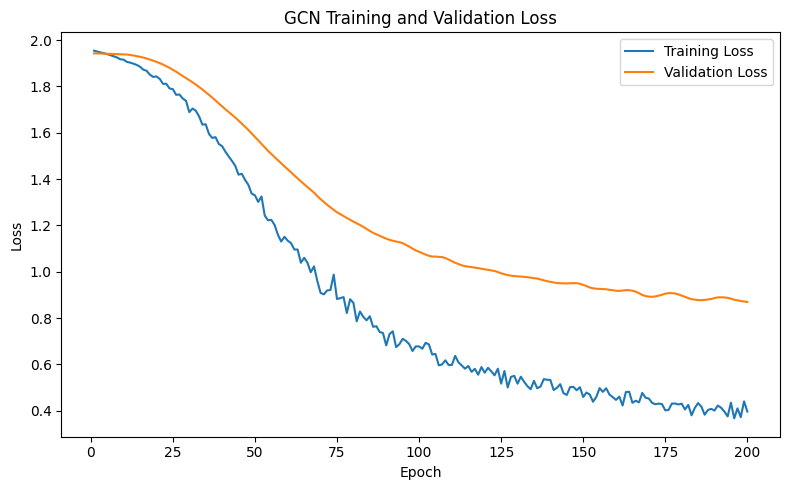

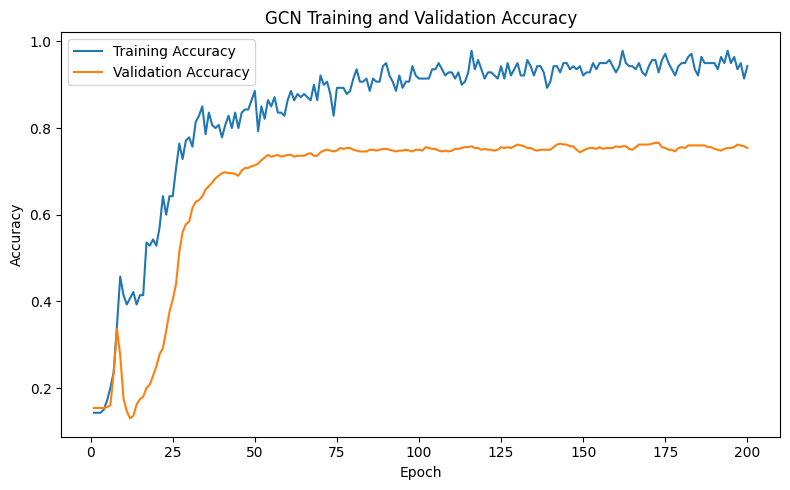

In [12]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Training Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GCN Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Training Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GCN Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


# 13. Evaluate the Model on the Test Set

Evaluate the best checkpoint on the held-out test nodes.

In [13]:
model.eval()

with torch.no_grad():
    logits = model(X_tensor, adj_norm)

    test_loss = F.cross_entropy(
        logits[test_mask],
        y_tensor[test_mask]
    ).item()

    predictions = logits[test_mask].argmax(dim=1).cpu().numpy()
    targets = y_tensor[test_mask].cpu().numpy()

test_accuracy = accuracy_score(targets, predictions)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    targets,
    predictions,
    average="macro",
    zero_division=0
)

_, _, f1_weighted, _ = precision_recall_fscore_support(
    targets,
    predictions,
    average="weighted",
    zero_division=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1: {f1_macro:.4f}")
print(f"Weighted F1: {f1_weighted:.4f}")


Test Loss: 0.8057
Test Accuracy: 0.7870
Macro Precision: 0.7599
Macro Recall: 0.7993
Macro F1: 0.7751
Weighted F1: 0.7877


# 14. Classification Report

Review precision, recall, and F1-score for each paper category.

In [14]:
print(
    classification_report(
        targets,
        predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


                        precision    recall  f1-score   support

            Case_Based     0.6829    0.8000    0.7368       105
    Genetic_Algorithms     0.9212    0.9268    0.9240       164
       Neural_Networks     0.8640    0.7630    0.8103       308
 Probabilistic_Methods     0.7639    0.7051    0.7333       156
Reinforcement_Learning     0.7381    0.8493    0.7898        73
         Rule_Learning     0.6444    0.8788    0.7436        66
                Theory     0.7049    0.6719    0.6880       128

              accuracy                         0.7870      1000
             macro avg     0.7599    0.7993    0.7751      1000
          weighted avg     0.7947    0.7870    0.7877      1000



# 15. Confusion Matrix

Visualize the categories that are most often confused.

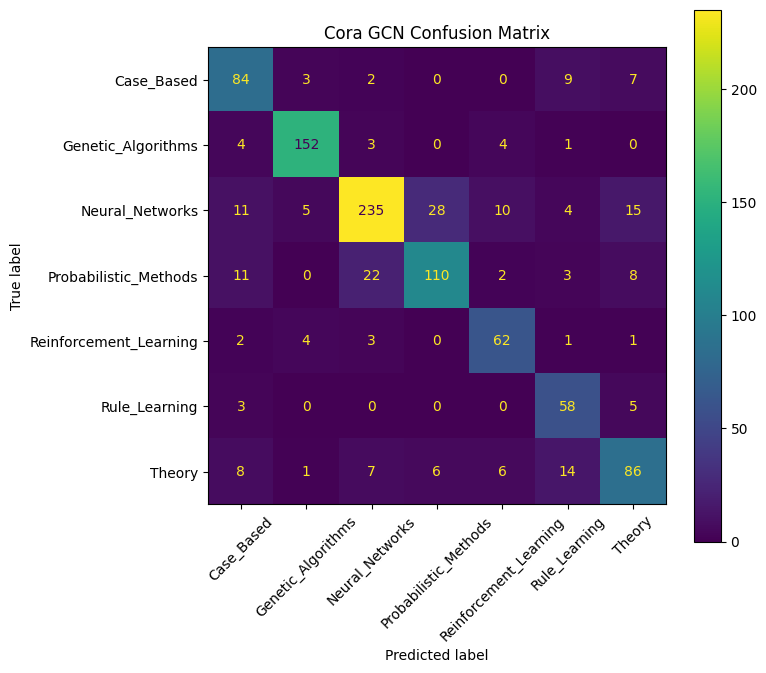

In [15]:
cm = confusion_matrix(targets, predictions)

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(
    ax=ax,
    xticks_rotation=45
)

ax.set_title("Cora GCN Confusion Matrix")
plt.tight_layout()
plt.show()


# 16. Visualize Learned Node Embeddings

Project the learned hidden representations into two dimensions to inspect class separation.

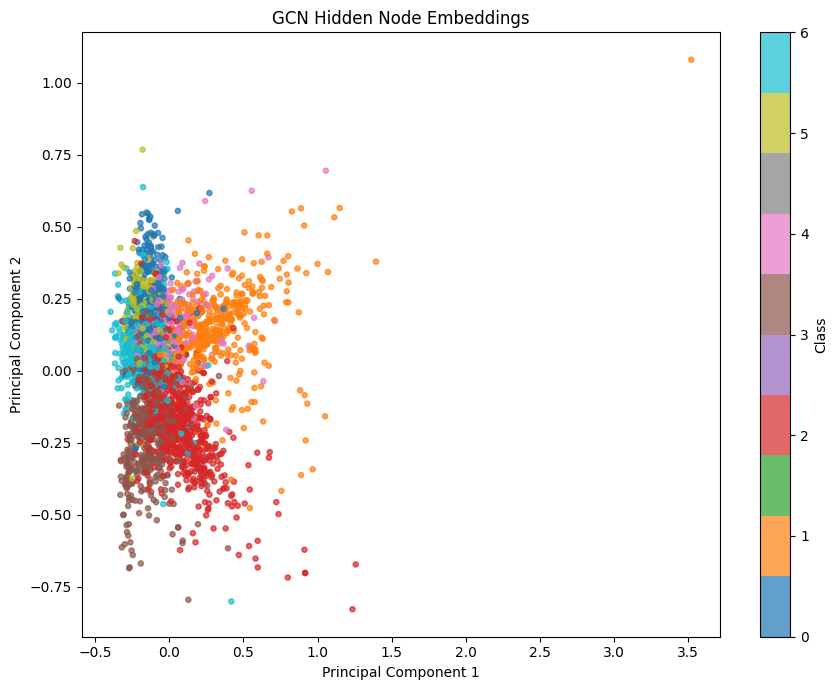

In [16]:
model.eval()

with torch.no_grad():
    embeddings = F.relu(
        model.conv1(X_tensor, adj_norm)
    ).cpu().numpy()

embedding_2d = PCA(
    n_components=2,
    random_state=SEED
).fit_transform(embeddings)

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=y,
    s=14,
    alpha=0.7,
    cmap="tab10"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GCN Hidden Node Embeddings")
plt.colorbar(scatter, label="Class")
plt.tight_layout()
plt.show()


# 17. Graph Structure and Degree Distribution

Examine the citation network and its node-degree distribution.

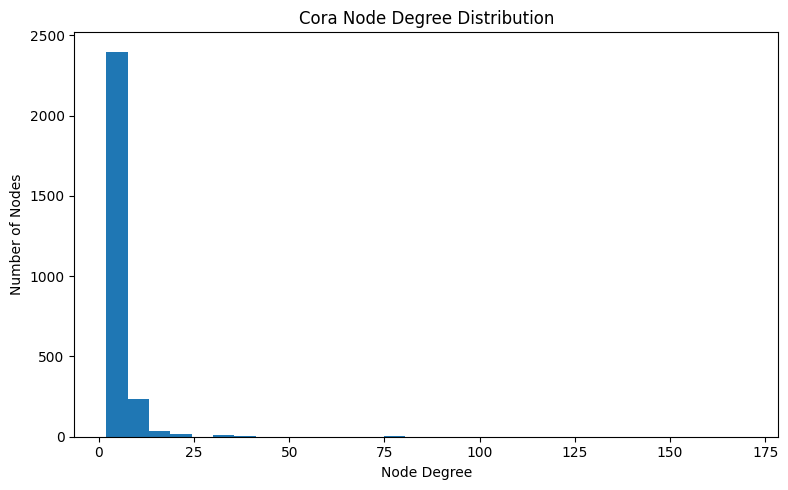

Graph nodes: 2708
Graph edges: 5278


In [17]:
graph = nx.Graph()

graph.add_nodes_from(range(num_nodes))

graph.add_edges_from(
    (int(i), int(j))
    for i, j in edge_array
    if i != j
)

degree_np = degree.cpu().numpy()

plt.figure(figsize=(8, 5))
plt.hist(degree_np, bins=30)
plt.xlabel("Node Degree")
plt.ylabel("Number of Nodes")
plt.title("Cora Node Degree Distribution")
plt.tight_layout()
plt.show()

print("Graph nodes:", graph.number_of_nodes())
print("Graph edges:", graph.number_of_edges())


# 18. Key Findings



# 19. Conclusion

